In [ ]:
#importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# setting the style of the plots to 'ggplot'
plt.style.use('ggplot')
#reading the csv files into pandas dataframes
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [44]:
print(df1.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [45]:
print(df2.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [46]:
print(df1.shape)
print(df2.shape)

(768, 7)
(267, 9)


In [47]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 66.1 KB


In [48]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    str    
 1    Date                                     267 non-null    str    
 2    Frequency                                267 non-null    str    
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    str    
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), str(4)
memory usage: 26.0 KB


In [49]:
df1.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [50]:
df2.isnull().sum()

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64

In [ ]:
# Error was coming while converting the date column 
# to datetime format because there were leading spaces
# in the column names.
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%m-%Y')

KeyError: 'Date'

In [ ]:
# we check if colums have spaces in their names, 
# if yes we will remove them 
print(df1.columns)
print(df2.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='str')


In [ ]:
# we remove the leading spaces in the column names 
# using str.strip() method
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [ ]:
# Error has occured because the date values have 
# leading spaces in them. We will use str.strip() method]
# to remove the leading spaces in the date values and then
# convert the date column to datetime format.
df1['Date'] = pd.to_datetime(df1['Date'], format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'], format='%d-%m-%Y')

ValueError: time data " 31-05-2019" doesn't match format "%d-%m-%Y". You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
# Python was treating the date column as an object type, 
# so we need to convert it to datetime format. 
# The below code will convert the date column to datetime
# format and also strip any leading or trailing spaces 
# from the date strings.

df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df2['Date'] = pd.to_datetime(df2['Date'].str.strip(), format='%d-%m-%Y')


In [ ]:
#axis=0 means we are moving down the rows, 
#axis=1 means we are moving across the columns.
# we check null values
df1[df1.isnull().any(axis=1)]

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
359,NaN,NaT,NaN,NaN,NaN,NaN,NaN
360,NaN,NaT,NaN,NaN,NaN,NaN,NaN
361,NaN,NaT,NaN,NaN,NaN,NaN,NaN
362,NaN,NaT,NaN,NaN,NaN,NaN,NaN
363,NaN,NaT,NaN,NaN,NaN,NaN,NaN
364,NaN,NaT,NaN,NaN,NaN,NaN,NaN
365,NaN,NaT,NaN,NaN,NaN,NaN,NaN
366,NaN,NaT,NaN,NaN,NaN,NaN,NaN
367,NaN,NaT,NaN,NaN,NaN,NaN,NaN
368,NaN,NaT,NaN,NaN,NaN,NaN,NaN


In [ ]:
# we dropped the null values
df1.dropna(inplace=True)

In [63]:
df1.info

<bound method DataFrame.info of              Region       Date Frequency  Estimated Unemployment Rate (%)  \
0    Andhra Pradesh 2019-05-31   Monthly                             3.65   
1    Andhra Pradesh 2019-06-30   Monthly                             3.05   
2    Andhra Pradesh 2019-07-31   Monthly                             3.75   
3    Andhra Pradesh 2019-08-31   Monthly                             3.32   
4    Andhra Pradesh 2019-09-30   Monthly                             5.17   
..              ...        ...       ...                              ...   
749     West Bengal 2020-02-29   Monthly                             7.55   
750     West Bengal 2020-03-31   Monthly                             6.67   
751     West Bengal 2020-04-30   Monthly                            15.63   
752     West Bengal 2020-05-31   Monthly                            15.22   
753     West Bengal 2020-06-30   Monthly                             9.86   

     Estimated Employed  Estimated Labour P

In [64]:
df2.info

<bound method DataFrame.info of              Region       Date Frequency  Estimated Unemployment Rate (%)  \
0    Andhra Pradesh 2020-01-31         M                             5.48   
1    Andhra Pradesh 2020-02-29         M                             5.83   
2    Andhra Pradesh 2020-03-31         M                             5.79   
3    Andhra Pradesh 2020-04-30         M                            20.51   
4    Andhra Pradesh 2020-05-31         M                            17.43   
..              ...        ...       ...                              ...   
262     West Bengal 2020-06-30         M                             7.29   
263     West Bengal 2020-07-31         M                             6.83   
264     West Bengal 2020-08-31         M                            14.87   
265     West Bengal 2020-09-30         M                             9.35   
266     West Bengal 2020-10-31         M                             9.98   

     Estimated Employed  Estimated Labour P

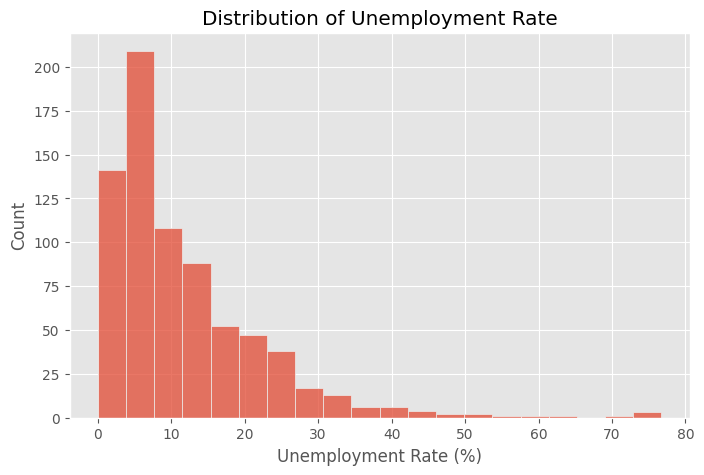

In [69]:
plt.figure(figsize=(8,5))

sns.histplot(
    df1['Estimated Unemployment Rate (%)'],
    bins=20
)

plt.title("Distribution of Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Count")

plt.savefig(
    "images/unemployment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
state_unemployment = (
    df1.groupby('Region')
    ['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

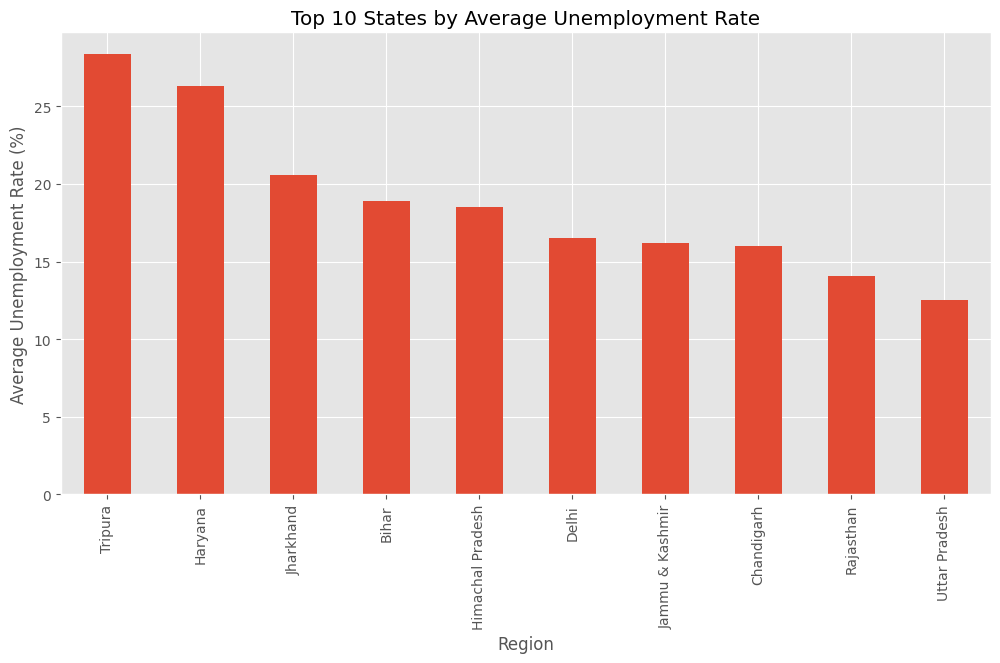

In [71]:
plt.figure(figsize=(12,6))

state_unemployment.head(10).plot(kind='bar')

plt.title("Top 10 States by Average Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")

plt.savefig(
    "images/top_states_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

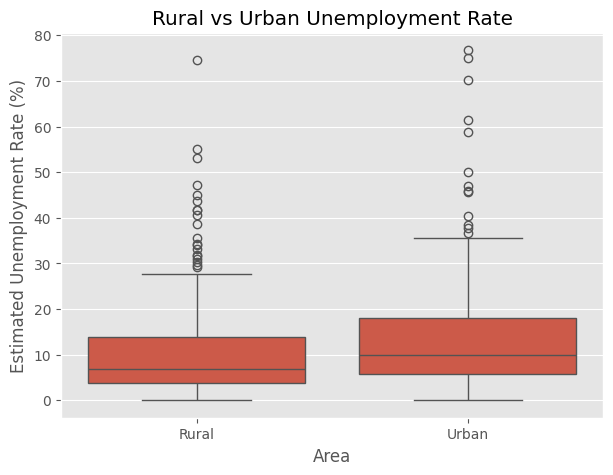

In [72]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df1,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Rural vs Urban Unemployment Rate")

plt.savefig("images/rural_vs_urban.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [73]:
monthly_unemployment = (
    df2.groupby("Date")["Estimated Unemployment Rate (%)"]
    .mean()
)

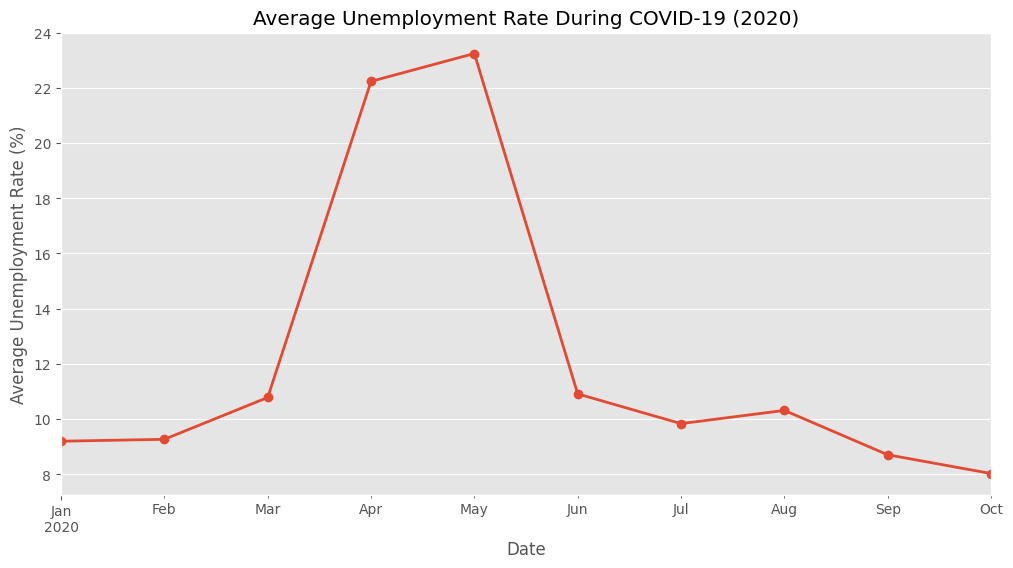

In [74]:
plt.figure(figsize=(12,6))

monthly_unemployment.plot(
    marker="o",
    linewidth=2
)

plt.title("Average Unemployment Rate During COVID-19 (2020)")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.savefig(
    "images/covid_unemployment_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [75]:
monthly_unemployment.sort_values(
    ascending=False
).head()

Date
2020-05-31    23.244444
2020-04-30    22.236154
2020-06-30    10.911111
2020-03-31    10.782593
2020-08-31    10.313333
Name: Estimated Unemployment Rate (%), dtype: float64

In [76]:
regional_avg = (
    df2.groupby("Region.1")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

regional_avg

Region.1
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Estimated Unemployment Rate (%), dtype: float64

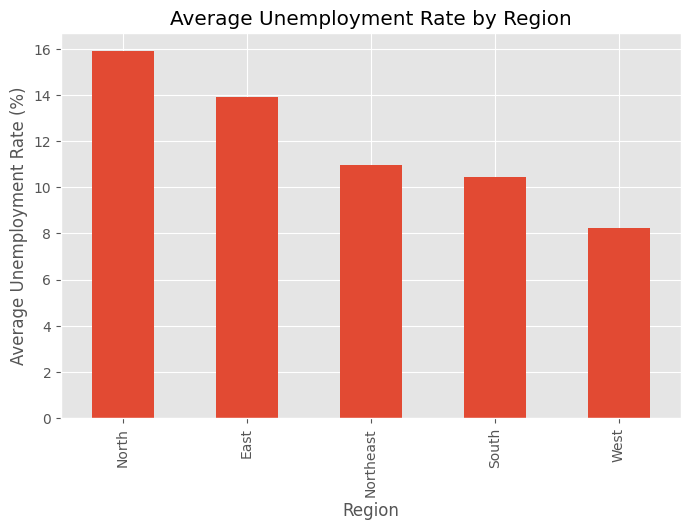

In [77]:
plt.figure(figsize=(8,5))

regional_avg.plot(
    kind="bar"
)

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.savefig(
    "images/regional_unemployment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

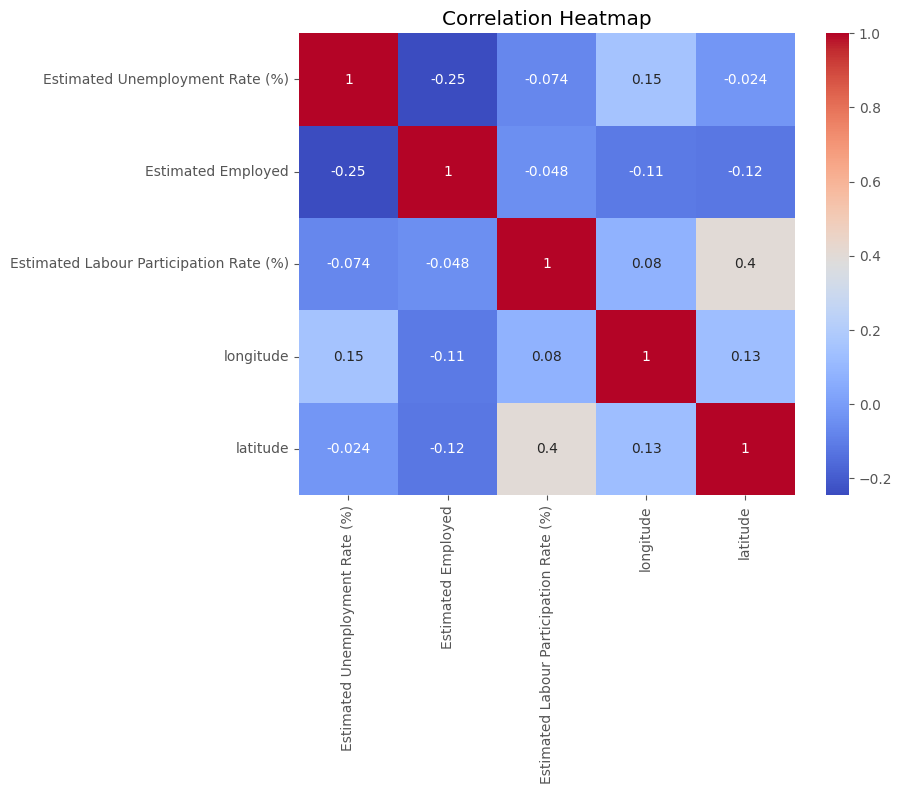

In [78]:
numeric_df = df2.select_dtypes(include="number")

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Insights

1. Unemployment rates increased sharply during the COVID-19 lockdown period.

2. April and May 2020 recorded the highest unemployment levels.

3. Employment levels decreased significantly during the pandemic.

4. Different regions experienced different levels of unemployment.

5. Rural and urban areas showed varying unemployment patterns.

6. The analysis demonstrates the economic impact of COVID-19 on India's workforce.